In [3]:
import psychometric_fxns as pf
import psignifit as ps
import psignifit.psigniplot as psp
import matplotlib.pyplot as plt

In [4]:
import os

repo_dir = os.getcwd()
data_dir = os.path.join(repo_dir, 'tilt_mocs','data')
#loop thru subjects (only the directories that start with sub there are no letters after sub just numbers, so not sub-eliza but yes sub-21040096)
all_subs = [d for d in os.listdir(data_dir) if d.startswith('sub-') and d[4:].isdigit()]
#get the subs whose IDs are greater than or equal to 21049995
stair_subs = [d for d in all_subs if int(d[4:]) >= 21049995]
#get the subs whose IDs are less than 21049995
fixed_subs = [d for d in all_subs if int(d[4:]) < 21049995]
#get the subs whose IDs are less than 21040200 but greater than 21040098
real_subs = [d for d in all_subs if int(d[4:]) < 21040200 and int(d[4:]) > 21040098]

# Collect all subject data
data_files = {}
for sub in real_subs:
    data_files[sub] = {}
    sub_path = os.path.join(data_dir, sub)
    if os.path.exists(sub_path):
        # Look for ses- folders
        sessions = sorted([s for s in os.listdir(sub_path) if s.startswith('ses-')])
        for ses in sessions:
            sub_data_dir = os.path.join(sub_path, ses)
            if os.path.isdir(sub_data_dir):
                csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')]
                if csv_files:
                    data_files[sub][ses] = os.path.join(sub_data_dir, csv_files[0])

subject psilocybin sessions:
99: 1
100: 1
102: 2
105: 2

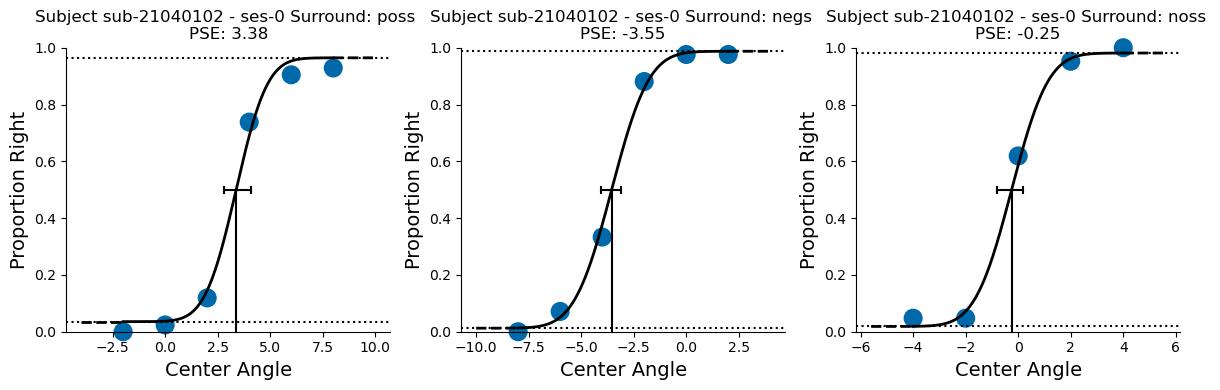

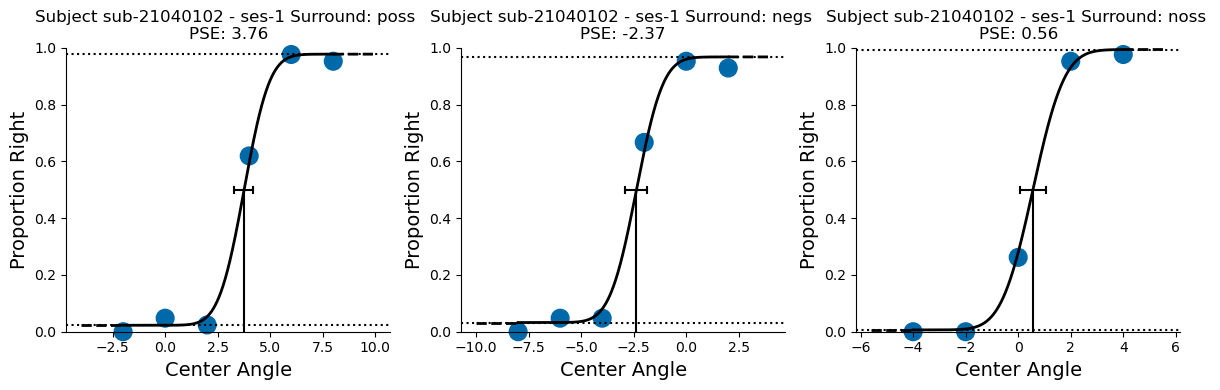

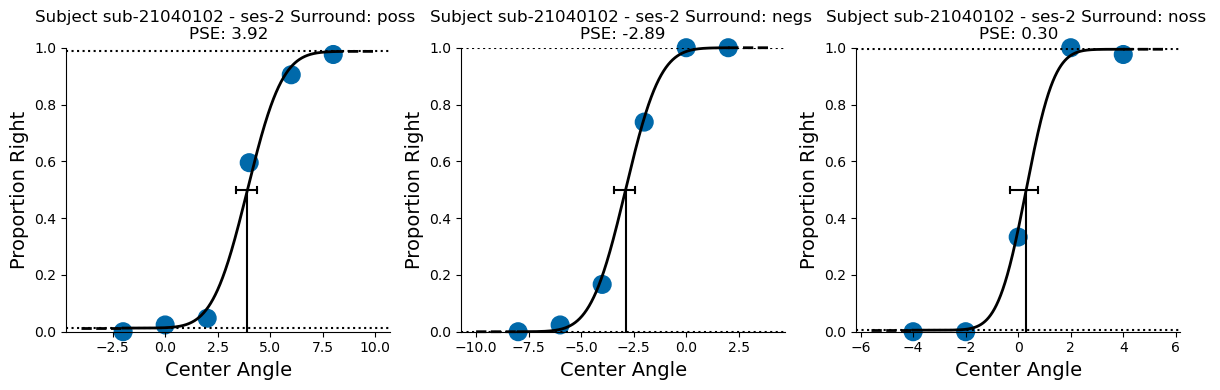

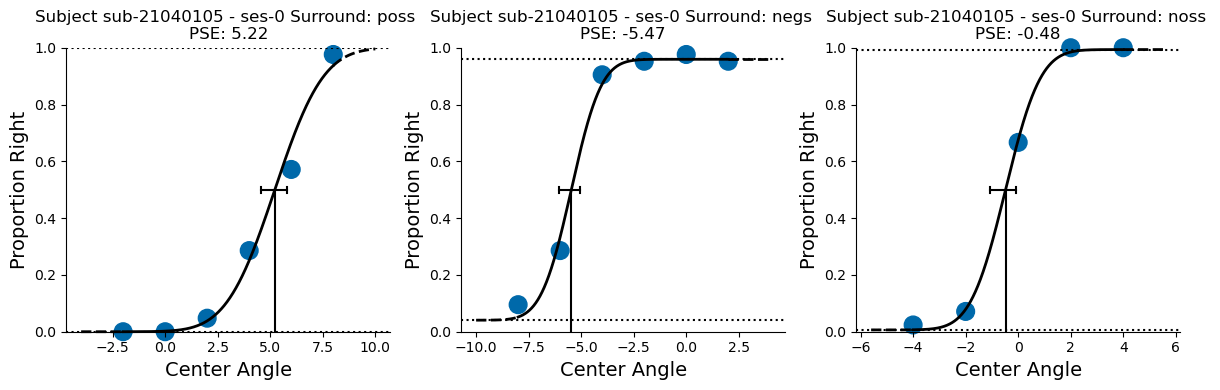

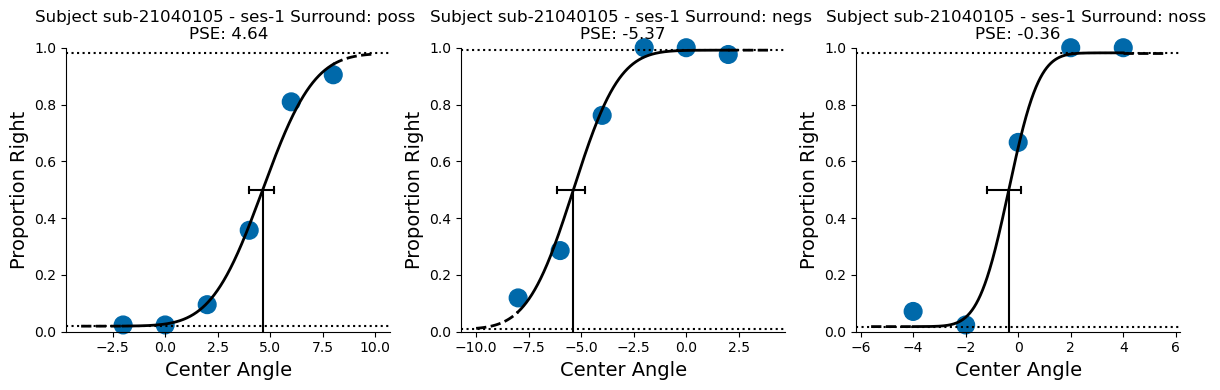

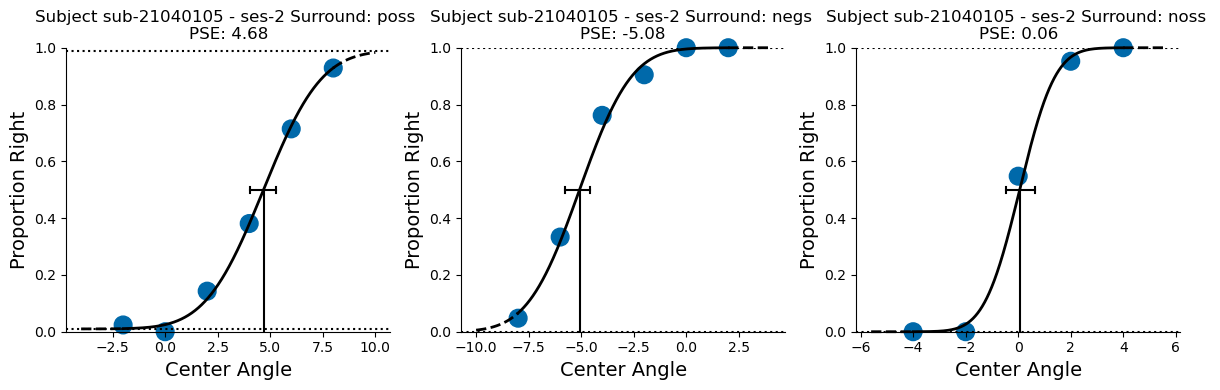

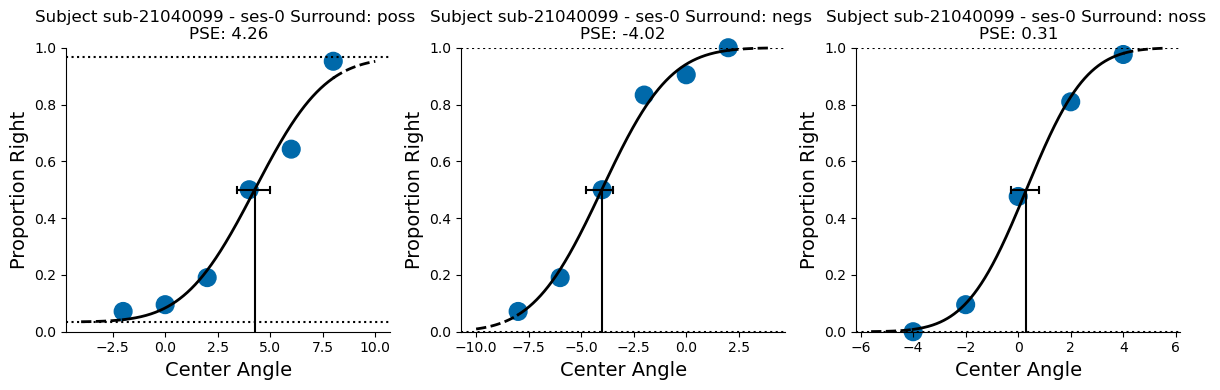

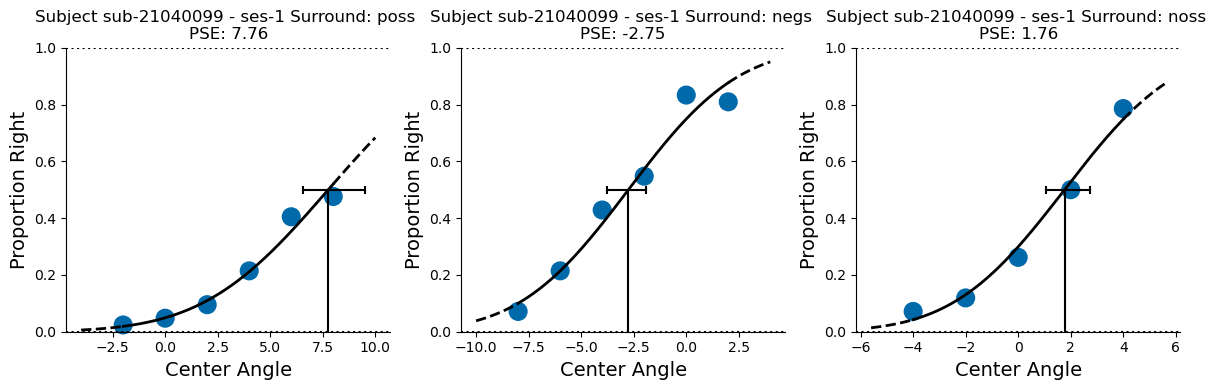

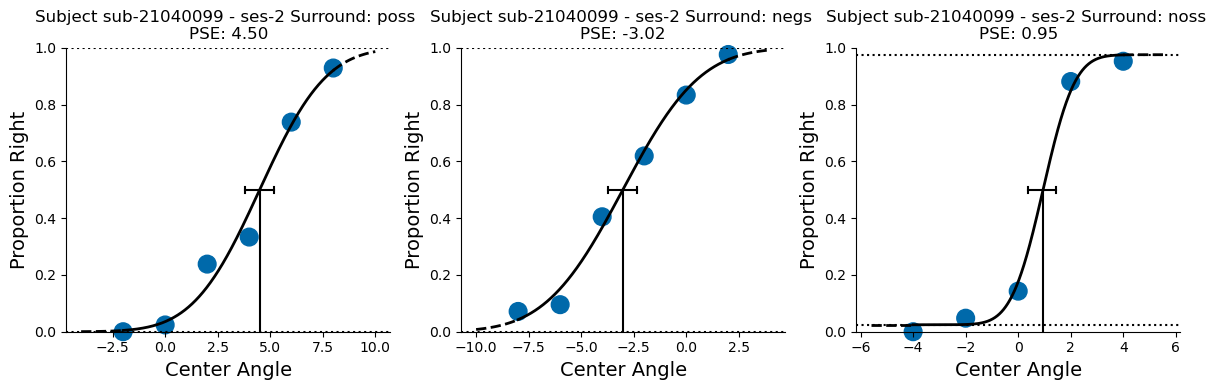

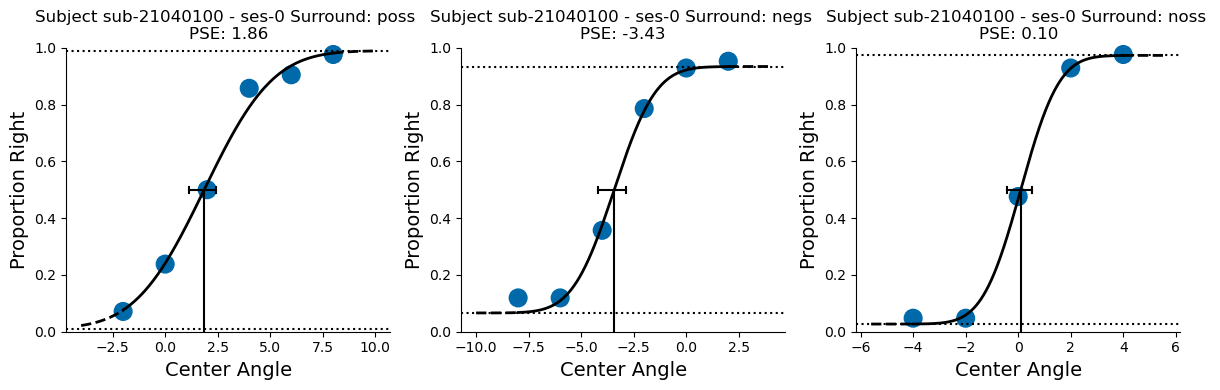

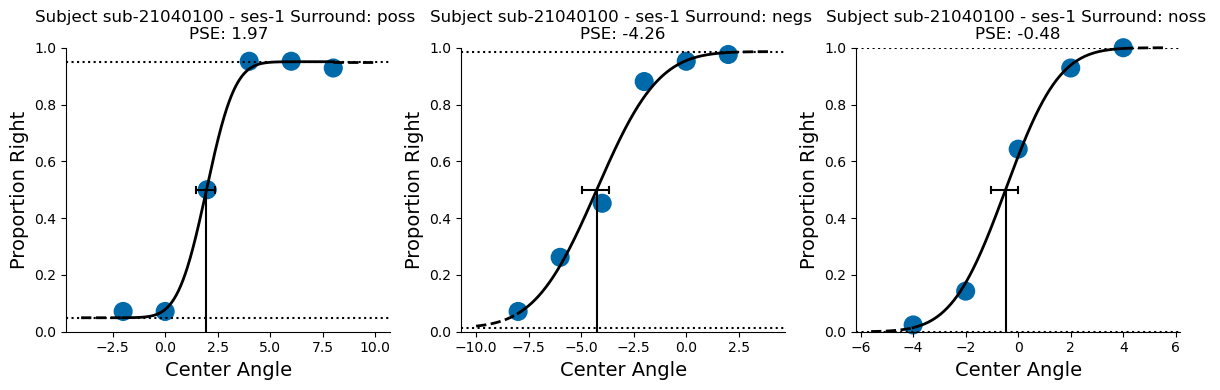

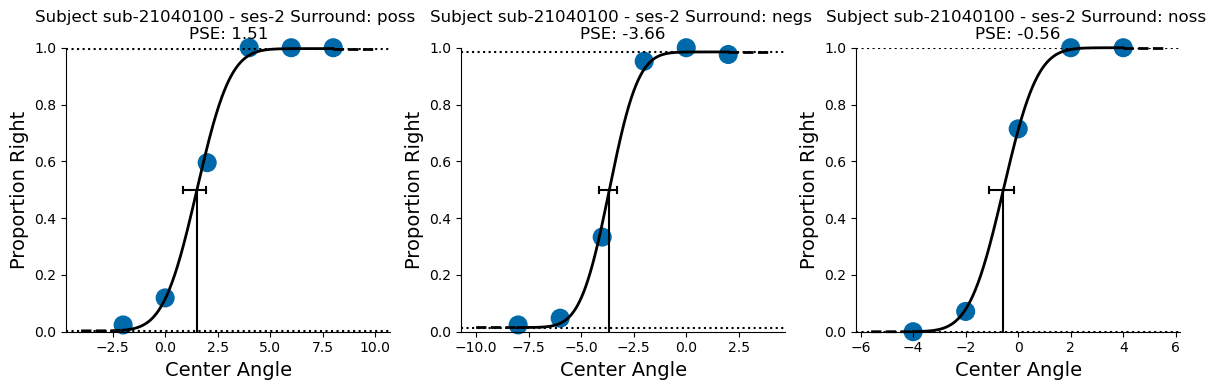

In [5]:
# plot each subject's psychometric function individually (already there)
# also create a mega plot with all of the individual plots on one figure
for sub, sessions in data_files.items():
    for ses, file_path in sessions.items():
        test = pf.get_psignifit_data_from_mocs_csv(file_path)
        fit_results = pf.fit_psychometric_fxn(test)
        pf.plot_psychometric_fxns(fit_results, f'{sub} - {ses}')
        plt.show()

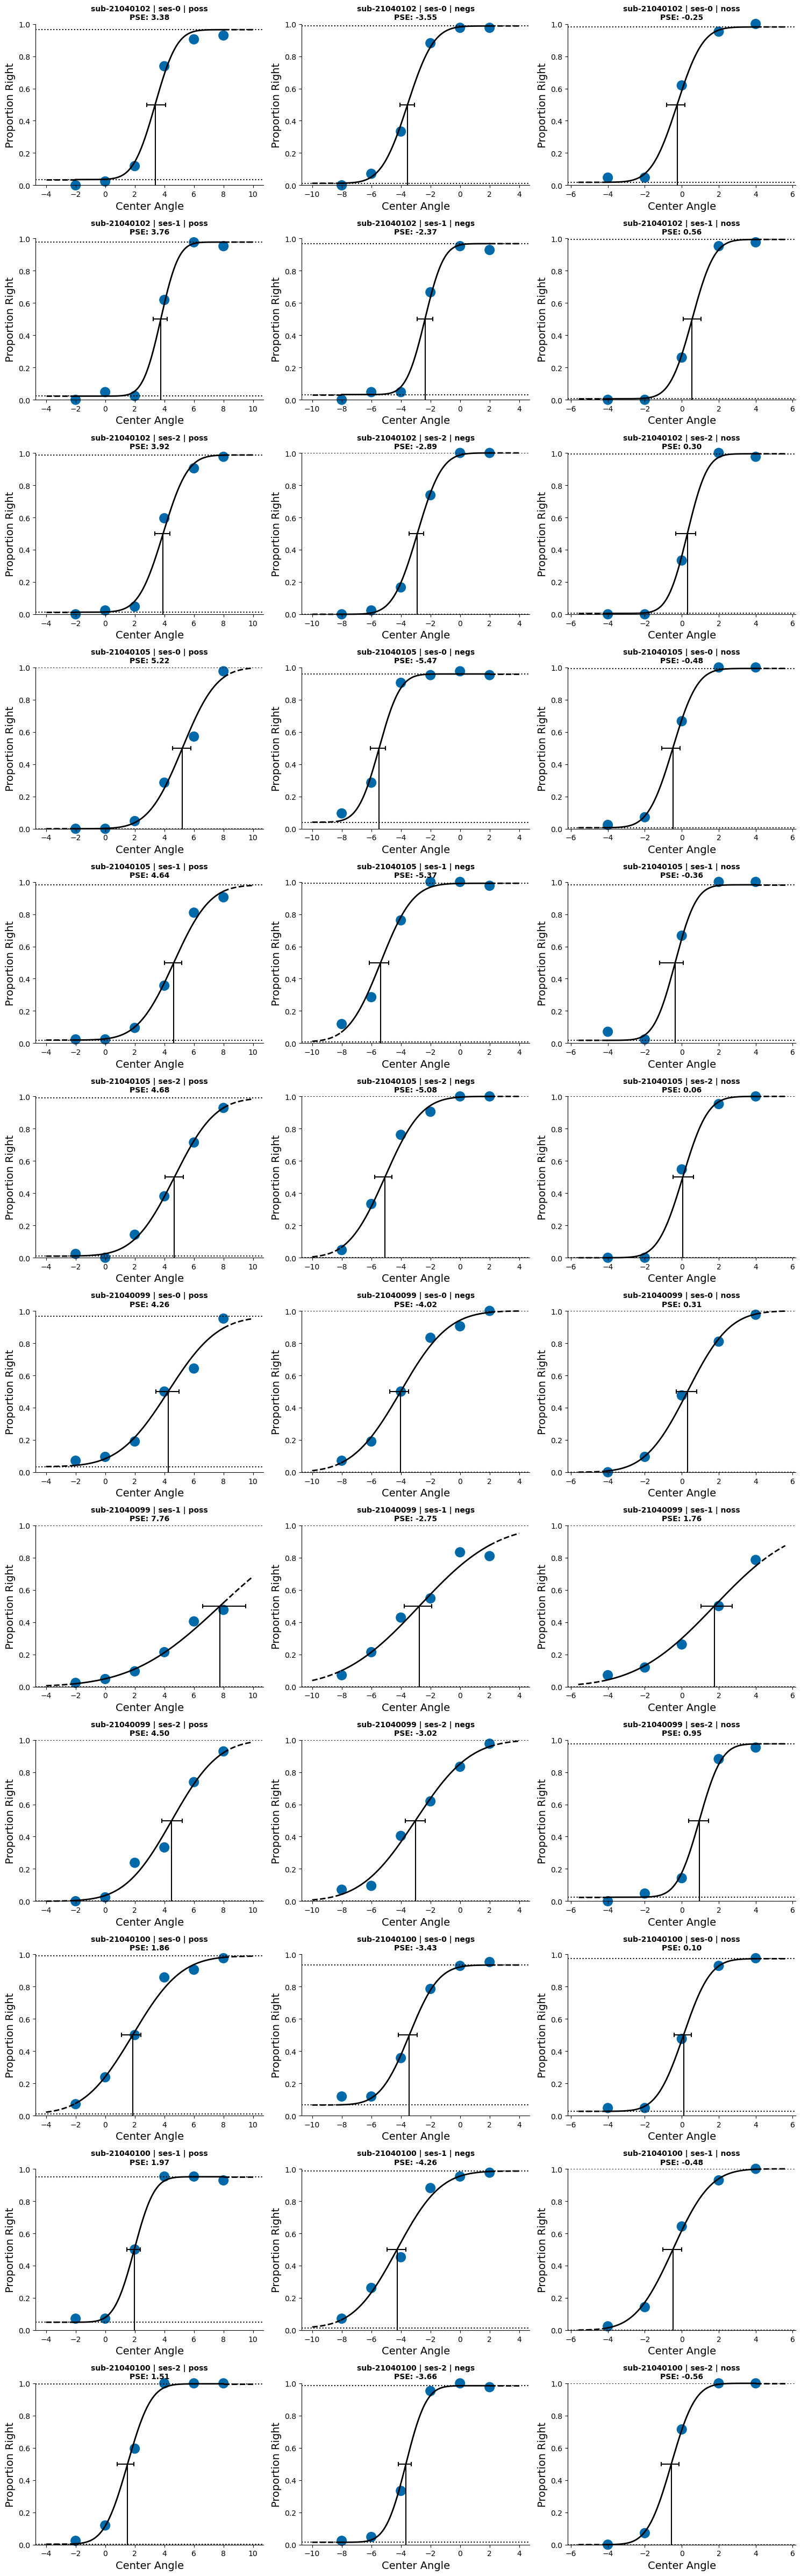

In [6]:
import numpy as np

# Create mega plot with one big figure
total_sessions = sum(len(sessions) for sessions in data_files.values())

if total_sessions > 0:
    n_cols = 3  # 3 surround conditions per subject
    n_rows = total_sessions

    fig = plt.figure(figsize=(15, 4*n_rows))

    plot_idx = 1
    for sub, sessions in data_files.items():
        for ses in sorted(sessions.keys()):
            file_path = sessions[ses]
            test = pf.get_psignifit_data_from_mocs_csv(file_path)
            fit_results = pf.fit_psychometric_fxn(test)
            
            # Plot each surround type
            for i, surround_cond in enumerate(['poss', 'negs', 'noss']):
                ax = plt.subplot(n_rows, n_cols, plot_idx)
                fit_result = fit_results[surround_cond]
                psp.plot_psychometric_function(fit_result)
                
                pse = fit_result.parameter_estimate['threshold']
                ax.set_title(f'{sub} | {ses} | {surround_cond}\nPSE: {pse:.2f}', fontsize=10, fontweight='bold')
                ax.set_xlabel('Center Angle')
                ax.set_ylabel('Proportion Right')
                
                plot_idx += 1

    plt.tight_layout()
    plt.savefig('psychometric_functions_all_subjects.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No data found to plot.")

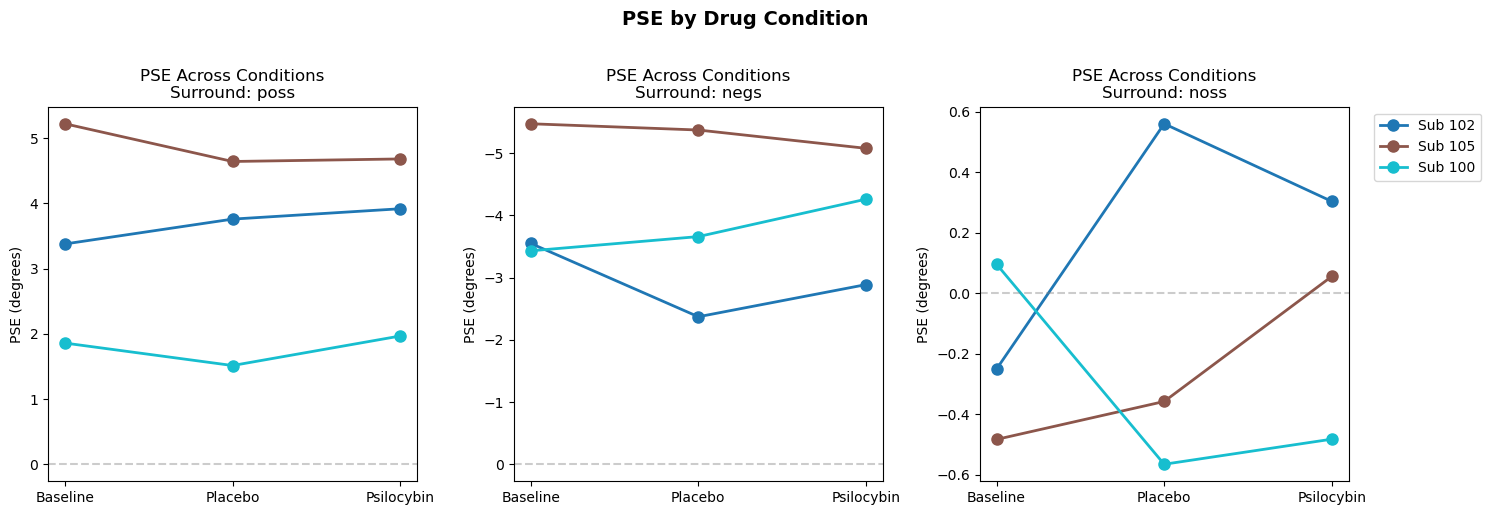

In [8]:
# PSE comparison: baseline vs placebo vs psilocybin
# ses-0 = baseline; psilocybin session per subject:
#   100 -> ses-1 (placebo = ses-2)
#   102 -> ses-2 (placebo = ses-1)
#   105 -> ses-2 (placebo = ses-1)

psil_session_map = {
    'sub-21040100': 'ses-1',
    'sub-21040102': 'ses-2',
    'sub-21040105': 'ses-2',
}
exclude_subs = {'sub-21040099'}

# Fit all sessions and collect PSEs
pse_data = {}  # pse_data[sub][condition][surround_cond] = PSE value

for sub, sessions in data_files.items():
    if sub in exclude_subs or sub not in psil_session_map:
        continue

    pse_data[sub] = {}
    psil_ses = psil_session_map[sub]

    for ses, file_path in sessions.items():
        test = pf.get_psignifit_data_from_mocs_csv(file_path)
        fit_results = pf.fit_psychometric_fxn(test)

        if ses == 'ses-0':
            condition = 'baseline'
        elif ses == psil_ses:
            condition = 'psilocybin'
        else:
            condition = 'placebo'

        pse_data[sub][condition] = {
            sc: fit_results[sc].parameter_estimate['threshold']
            for sc in ['poss', 'negs', 'noss']
        }

# --- Plot ---
colors = plt.cm.tab10(np.linspace(0, 1, len(pse_data)))
conditions = ['baseline', 'placebo', 'psilocybin']
x_pos = [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax_idx, surround_cond in enumerate(['poss', 'negs', 'noss']):
    ax = axes[ax_idx]

    for sub_idx, (sub, cond_data) in enumerate(pse_data.items()):
        color = colors[sub_idx]
        sub_num = sub.split('-')[1][-3:]  # last 3 digits: '100', '102', '105'

        x_vals, y_vals = [], []
        for cond_idx, cond in enumerate(conditions):
            if cond in cond_data:
                x_vals.append(x_pos[cond_idx])
                y_vals.append(cond_data[cond][surround_cond])

        ax.plot(x_vals, y_vals, 'o-', color=color, label=f'Sub {sub_num}', linewidth=2, markersize=8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Baseline', 'Placebo', 'Psilocybin'])
    ax.set_ylabel('PSE (degrees)')
    ax.set_title(f'PSE Across Conditions\nSurround: {surround_cond}')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
    
    if surround_cond == 'negs':
        ax.invert_yaxis()

axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle('PSE by Drug Condition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pse_by_condition.png', dpi=300, bbox_inches='tight')
plt.show()
